In [6]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from dataclasses import replace

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.img_converter import ImgConverter
from converters.line_heuristics.line_converter import LineConverter
from converters.tile.nearest import Tile2SymbNearest

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
MAX_COLS = 20
MAX_LINES = 10
NUM_IMGS = 10
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


def make_converter(params: Params):
    converter = LineConverter(tile_converter=Tile2SymbNearest(symbols=SYMBOLS,
                                                              font=FONT,
                                                              **params.converter_args))

    return ImgConverter(converter, FONT)

In [7]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery

default_params = Params(max_cols=MAX_COLS,
                        max_lines=MAX_LINES,
                        font_path=FONT_PATH,
                        font_size=FONT_SIZE)

converter = make_converter(default_params)

line_height = int(default_params.font_size * 1.333)
col_width = int(line_height / 2)

results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    col_width=col_width,
                                    line_height=line_height,
                                    gens_per_step=default_params.gens_per_step)
    results.append(res_arr)

print_gallery(results, 3)

d:\CS Projects\python-playground\python-ascii-art\tests\experimental\grayscale\tile\../../../../src\converters\tile\nearest.py:39: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


----------------------------------------------------------------------
| '!+***rUmr**4Kt*!!>- | ]$$$@gQ}]@QQ@@@@}Q@B | Y9ONf!!!>jyy{sU#9l!. |
| ggggggggggggggggggyy | ?)(jQgQj!Y?{QQ){(/{; | ))jj;;;))(j;!;;;;::, |
| QQ@@@@MM@@@@@@@@@@Q[ | yyQ{@$|'!   )jj}{Qj( | jjj{|]$$M@@$QgjQ@Q@[ |
| Q@@@M;q;;Q@@@QQQQQQ[ | {jjj@QQj:   j[QQ}}}( | {j{(;"?Y){O{{{{(,JF' |
| QQQ@@@Q@@@@@@@@@QQQ[ | j{|]QQQQ; - j|QQ$Qj; | j{{{( !v!?!`.`!`!:j, |
| @@@@@@@@@@@@@@@@@QQ[ | {jj}@$QQl ,y(`!5{]|( | )))!!.j;;,,,jjgQQQQ[ |
| "'^^^^"^^^^^^""''''` | ``````'"` `````````` | ```````'``'``''''''` |
----------------------------------------------------------------------
-----------------------------------------------------------------
|       --------  | Qg$@M@@@pAQg@@ggjj@Q | QQjjjjj{OOQQQjjjjjj( |
| ::::::::::::::  | @Q@QMPQM$@@G$%O$$$@@ | QOOO9{j{;!jj{{)j)){( |
| {{{{{{{{{{{{{{: | jQg@@ggggQS(j}T!`'T0 | QQgyjj({{Y{QQj{jjjy( |
| QQQQQQQQQQQQQQ! | $OM@@$]|[-`)!`     ` | QQQQ{Qjj` ;jjggQQ{j( |
| jjQQ||{};jQQQj: | A#4TTTTQyw5

Min: 0.0456 | Max: 0.1719 | Mean: 0.1288 | Std: 0.0367
Min: 0.0510 | Max: 0.1645 | Mean: 0.1201 | Std: 0.0320
Min: 0.0627 | Max: 0.1606 | Mean: 0.1211 | Std: 0.0281
Min: 0.0315 | Max: 0.1867 | Mean: 0.1296 | Std: 0.0427


C:\Users\wojte\AppData\Local\Temp\ipykernel_14320\1502689756.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


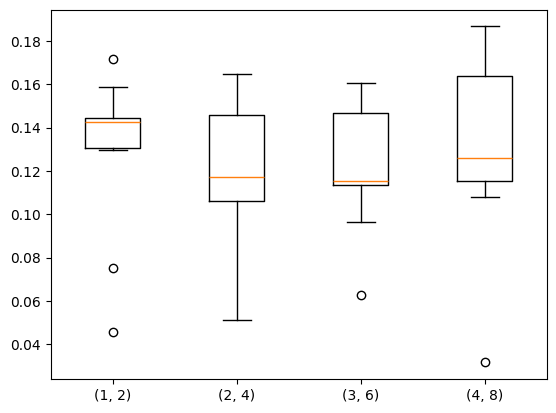

In [8]:
# val_wh

params_space = [
    (w, w * 2) for w in range(1, 5, 1)
]

params_space = list(
    map(lambda val_wh: replace(default_params, converter_args={'val_wh': val_wh}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['val_wh'] for param in params_space])
plt.show()

Min: 0.0461 | Max: 0.1167 | Mean: 0.0813 | Std: 0.0211
Min: 0.0683 | Max: 0.1553 | Mean: 0.1165 | Std: 0.0251
Min: 0.0640 | Max: 0.1920 | Mean: 0.1394 | Std: 0.0360
Min: 0.0640 | Max: 0.2237 | Mean: 0.1574 | Std: 0.0449
Min: 0.0540 | Max: 0.2507 | Mean: 0.1718 | Std: 0.0595


C:\Users\wojte\AppData\Local\Temp\ipykernel_14320\2305421242.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


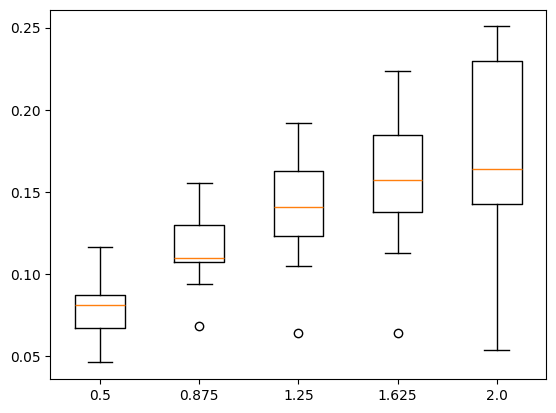

In [9]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: replace(default_params, preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

Min: 0.0627 | Max: 0.1606 | Mean: 0.1211 | Std: 0.0281
Min: 0.0576 | Max: 0.1191 | Mean: 0.0920 | Std: 0.0167
Min: 0.0279 | Max: 0.5002 | Mean: 0.1698 | Std: 0.1381


C:\Users\wojte\AppData\Local\Temp\ipykernel_14320\1162874657.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


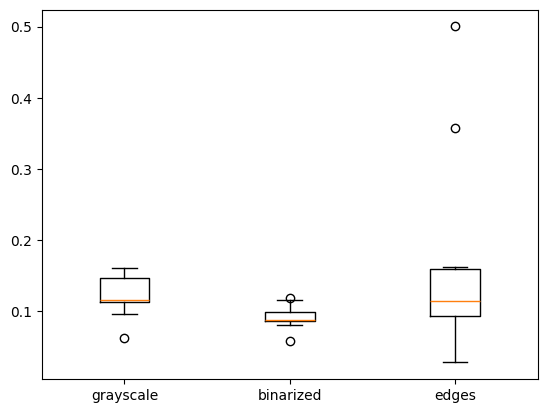

In [10]:
params_space = [default_params]
similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
             for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_BIN_PATHS, make_converter, params_space)

IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
             for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_EDGE_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=['grayscale', 'binarized', 'edges'])
plt.show()